<a href="https://colab.research.google.com/github/yiyangchen2020-afk/econ3916-lab01-data-portfolio/blob/main/lab_ch01_guided_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: The Data Portfolio — The Economic Lens
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 42 min Core + 15 min Extension

---

**Learning Objectives:**
- Load a real-world economic dataset into a pandas DataFrame
- Distinguish cross-sectional, time series, and panel data using the same dataset
- Compute Purchasing Power Parity (PPP) exchange rates from raw prices
- Diagnose missing data patterns and classify them as MCAR, MAR, or MNAR

**Dataset:** The Economist Big Mac Index (GitHub: TheEconomist/big-mac-data)

**Prerequisites:** none. Part 0 below teaches everything you are asked to *write* here — f-strings, boolean masks, double-bracket column selection, `.groupby()`. One GUIDED cell later *uses* a list comprehension with a ternary to colour a chart; you only need to read it, and Lab 8 introduces the form properly.

**Foundations First Policy:** Parts 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load the Big Mac Index
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the Big Mac Index from The Economist's GitHub repository
url = "https://raw.githubusercontent.com/TheEconomist/big-mac-data/master/output-data/big-mac-full-index.csv"
df = pd.read_csv(url, parse_dates=["date"])

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

# A fresh Colab session has no figures/ directory, and savefig will not
# create one. Make it now so every plot in this lab saves cleanly.
from pathlib import Path
Path("figures").mkdir(exist_ok=True)


Shape: (2056, 19)

Column types:
date             datetime64[ns]
iso_a3                   object
currency_code            object
name                     object
local_price             float64
dollar_ex               float64
dollar_price            float64
USD_raw                 float64
EUR_raw                 float64
GBP_raw                 float64
JPY_raw                 float64
CNY_raw                 float64
GDP_bigmac              float64
adj_price               float64
USD_adjusted            float64
EUR_adjusted            float64
GBP_adjusted            float64
JPY_adjusted            float64
CNY_adjusted            float64
dtype: object

First 5 rows:


<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 12 min)

**Read this before anything else, and run every cell.** This course assumes no
prior programming. Part 0 of Labs 1 through 5 is where that promise is kept —
each one teaches the slice of Python that lab needs, next to the data that
needs it. There is no separate primer to go and find.

**This lab's slice:** the notebook itself, f-strings, the DataFrame, the
boolean mask, and `.groupby()`. Everything Part 3 asks you to *write* is
demonstrated here first.

### The notebook

You are in a **notebook**: a document of **cells**, each holding prose or code.
Run a code cell with **Shift+Enter**; the output appears underneath.

- **Kernel** — the Python process behind the notebook. It remembers everything
  you have defined, and all cells share one, so **order matters**: skip a cell
  and the ones after it may fail on a name that was never created.
- **Restart** — *Runtime → Restart session* empties it. When a notebook behaves
  impossibly, restart and run from the top. This fixes more than anything else.

When a cell errors, read the **last** line of the message first. That is the
actual complaint; the wall above it is only the route Python took to get there.


In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0a: variables, types, and the f-string
# -----------------------------------------------------------

# A VARIABLE is a name bound to a value with a single = sign.
# Read `x = 5` as "let x refer to 5", never as "x equals 5".
country   = "Switzerland"   # a str   — text, in quotes
big_mac   = 7.10            # a float — Switzerland's price in Swiss francs
n_periods = 45              # an int  — a whole number
print(type(country), type(big_mac), type(n_periods))

# An F-STRING is a string with `f` before the opening quote. Anything inside
# { } is evaluated as Python and dropped into the text. It is the most-used
# construct in this course — roughly eighty of the cells you will write.
#
# The part after a COLON is a FORMAT SPEC. It controls how a number is
# DISPLAYED and never changes the underlying value:
#
#   :.1%    percent, 1 decimal        0.042 -> 4.2%
#   :.2f    fixed point, 2 decimals   7.1   -> 7.10
#   :,.0f   thousands separator       2056  -> 2,056
#   :<15    left-align in 15 columns   (for lining up tables)
valuation = 0.4176
print(f"{country}: CHF {big_mac:.2f}, valued {valuation:.1%} against the US")
# Units matter here: 7.10 is francs, not dollars. And `valuation` is a
# FRACTION (0.4176), which is why :.1% works. The lab's valuation_pct
# column is already multiplied by 100 (41.76) -- format that one with
# :.1f and a literal %, or :.1% will print 4175.6%.

# :.1% MULTIPLIES BY 100 for you. This is the single most common f-string bug:
print(f"WRONG: {valuation * 100:.1%}   <- 0.4176 * 100 = 41.76, shown as 4176.0%")
print(f"RIGHT: {valuation:.1%}")

# Alignment is how every summary table in these labs is built.
print()
for name, pct in [("Switzerland", 0.4176), ("Norway", 0.1894), ("Taiwan", -0.5990)]:
    print(f"  {name:<15}{pct:>8.1%}")

<class 'str'> <class 'float'> <class 'int'>
Switzerland: CHF 7.10, valued 41.8% against the US
WRONG: 4176.0%   <- 0.4176 * 100 = 41.76, shown as 4176.0%
RIGHT: 41.8%

  Switzerland       41.8%
  Norway            18.9%
  Taiwan           -59.9%


In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0b: the DataFrame, one bracket vs two, and boolean masks
# -----------------------------------------------------------

# `df` was loaded by the Setup cell above. A DATAFRAME is a table: named
# columns, ordered rows. The INDEX is the row labels down the left — it is not
# a column. A DTYPE is the type of a whole column, and a surprising number of
# pandas errors are really a dtype that is not what you assumed.
print(f"Shape (rows, columns): {df.shape}")
print(f"Countries: {df['name'].nunique()}   Periods: {df['date'].nunique()}")

# ONE pair of brackets with one name gives a SERIES — a single column.
# TWO pairs gives a DATAFRAME, because the inner brackets are a LIST of names.
# This is why the labs write df[["name", "local_price", "dollar_price"]].
print(f"\ndf['name']                  is a {type(df['name']).__name__}")
print(f"df[['name']]                is a {type(df[['name']]).__name__}")
print(f"df[['name','local_price']]  is a {type(df[['name', 'local_price']]).__name__}")

# A BOOLEAN MASK is the single most important pattern in this course.
# A comparison on a column gives one True/False PER ROW; putting that inside
# df[ ... ] keeps only the rows where it is True.
mask = df["date"] == "2024-07-01"
print(f"\nThe mask is {len(mask)} True/False values; {mask.sum()} are True.")
print(f"Countries in that cross-section: {len(df[mask])}")

# Combine with & (and), | (or), ~ (not) — NOT the words and/or/not, which
# raise "ValueError: The truth value of a Series is ambiguous".
# Each condition MUST be wrapped in its own parentheses:
#     df[(df["a"] > 1) & (df["b"] < 2)]     correct
#     df[ df["a"] > 1  &  df["b"] < 2 ]     wrong — & binds tighter than >
dear = df[(df["date"] == "2024-07-01") & (df["dollar_price"] > 6)]
print(f"\nBig Macs over $6 in July 2024: {len(dear)}")
print(dear[["name", "dollar_price"]].to_string(index=False))

# Filtering to one country is the same move, and you will write it in Part 3.
russia = df[df["name"] == "Russia"]
print(f"\nRussia appears {len(russia)} times; last on {russia['date'].max().date()}.")

Shape (rows, columns): (2056, 19)
Countries: 57   Periods: 45

df['name']                  is a Series
df[['name']]                is a DataFrame
df[['name','local_price']]  is a DataFrame

The mask is 2056 True/False values; 54 are True.
Countries in that cross-section: 54

Big Macs over $6 in July 2024: 5
       name  dollar_price
  Argentina      6.545246
Switzerland      8.065890
  Euro area      6.059753
     Norway      6.767571
    Uruguay      7.071960

Russia appears 36 times; last on 2022-01-01.


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0c: .groupby(), and masking what it hands back
# -----------------------------------------------------------

# .groupby(col) splits the table into one group per distinct value in that
# column, applies an aggregation to each group, and combines the answers.
# Split -> apply -> combine. That is the whole idea.
print("Mean dollar price by year (first five):")
print(df.groupby(df["date"].dt.year)["dollar_price"].mean().head().round(2))

# Counting how many periods each country appears in. This exact line is in
# Part 3, and what it returns is a SERIES indexed by country.
max_periods    = df["date"].nunique()
country_counts = df.groupby("name")["date"].count()
print(f"\ncountry_counts is a {type(country_counts).__name__} of "
      f"{len(country_counts)} countries. First three:")
print(country_counts.head(3))

# READ THIS TWICE — it is the shape Part 3 asks you to write.
# Everything above masked a DATAFRAME using one of its COLUMNS:
#     df[df["name"] == "Russia"]
# Here there is no column to name. The thing you compare and the thing you
# filter are the SAME Series:
complete = country_counts[country_counts == max_periods]
print(f"\nCountries present in all {max_periods} periods: {len(complete)} of {len(country_counts)}")

# Read it as: `country_counts == max_periods` is one True/False per COUNTRY,
# and putting that inside country_counts[ ... ] keeps the countries where it
# is True. Same rule as before; the only change is where the mask came from.
# len() of the result counts COUNTRIES, not rows of df.

Mean dollar price by year (first five):
date
2000    2.06
2001    1.88
2002    2.04
2003    2.15
2004    2.23
Name: dollar_price, dtype: float64

country_counts is a Series of 57 countries. First three:
name
Argentina     45
Australia     45
Azerbaijan    17
Name: date, dtype: int64

Countries present in all 45 periods: 25 of 57


## Part 1: Data Structure Exploration (GUIDED — 10 min)

The Big Mac Index is a **panel dataset** — many countries observed over many time periods.
From this single dataset, we can extract all three data structures.

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Extract the three data structures from one dataset
# -----------------------------------------------------------

# How many countries and time periods?
n_countries = df["name"].nunique()
n_periods = df["date"].nunique()
print(f"Countries: {n_countries}, Time periods: {n_periods}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print()

# CROSS-SECTIONAL: All countries in July 2024 (one snapshot)
df_cross = df[df["date"] == "2024-07-01"][["name", "local_price", "dollar_price"]]
print(f"Cross-sectional (July 2024): {df_cross.shape[0]} countries, 1 time period")
print()

# TIME SERIES: Switzerland across all periods (one country, many times)
df_ts = df[df["name"] == "Switzerland"][["date", "local_price", "dollar_price"]]
print(f"Time series (Switzerland): 1 country, {df_ts.shape[0]} time periods")
print()

# PANEL: All countries across all periods
print(f"Panel (full dataset): {n_countries} countries x {n_periods} periods = {df.shape[0]} observations")
print(f"  (Unbalanced — not all countries appear in all periods)")

Countries: 57, Time periods: 45
Date range: 2000-04-01 to 2026-07-01

Cross-sectional (July 2024): 54 countries, 1 time period

Time series (Switzerland): 1 country, 45 time periods

Panel (full dataset): 57 countries x 45 periods = 2056 observations
  (Unbalanced — not all countries appear in all periods)


### Interpretation Questions (answer in the cell below)

1. Why is the panel "unbalanced"? What does that mean practically?
2. If you wanted to ask "Which country has the most expensive Big Mac right now?", which structure would you use?
3. If you wanted to ask "Has Switzerland's Big Mac price been rising over time?", which structure would you use?

*Your answers here:*

1.
2.
3.

## Part 2: Computing PPP — The Big Mac Index (GUIDED — 10 min)

Purchasing Power Parity says exchange rates should equalize prices across countries.
The Big Mac Index tests this with one product.

In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compute implied PPP and valuation for July 2024
# -----------------------------------------------------------

# Work with the July 2024 cross-section
df_2024 = df[df["date"] == "2024-07-01"].copy()

# Find the US Big Mac price as our benchmark
us_price = df_2024.loc[df_2024["iso_a3"] == "USA", "dollar_price"].values[0]
print(f"US Big Mac price: ${us_price:.2f}")

# Compute implied PPP: what exchange rate would equalize Big Mac prices?
df_2024["implied_ppp"] = df_2024["local_price"] / us_price

# Compute valuation: how far is the actual rate from PPP?
df_2024["valuation_pct"] = (
    (df_2024["implied_ppp"] - df_2024["dollar_ex"]) / df_2024["dollar_ex"] * 100
)

# Display the most overvalued and undervalued
cols = ["name", "local_price", "dollar_price", "implied_ppp", "dollar_ex", "valuation_pct"]

print("\n--- Most OVERVALUED (expensive) ---")
print(df_2024.nlargest(5, "valuation_pct")[cols].to_string(index=False))

print("\n--- Most UNDERVALUED (cheap) ---")
print(df_2024.nsmallest(5, "valuation_pct")[cols].to_string(index=False))

US Big Mac price: $5.69

--- Most OVERVALUED (expensive) ---
       name  local_price  dollar_price  implied_ppp  dollar_ex  valuation_pct
Switzerland          7.1      8.065890     1.247803    0.88025      41.755543
    Uruguay        285.0      7.071960    50.087873   40.30000      24.287527
     Norway         74.0      6.767571    13.005272   10.93450      18.937971
  Argentina       6100.0      6.545246  1072.056239  931.97420      15.030678
  Euro area          5.6      6.059753     0.984183    0.92413       6.498304

--- Most UNDERVALUED (cheap) ---
        name  local_price  dollar_price  implied_ppp   dollar_ex  valuation_pct
      Taiwan         75.0      2.281716    13.181019    32.87000     -59.899546
   Indonesia      40000.0      2.460025  7029.876977 16260.00000     -56.765824
       Egypt        120.0      2.469136    21.089631    48.60000     -56.605698
       India        219.0      2.615589    38.488576    83.72875     -54.031827
South Africa         51.9      2.8530

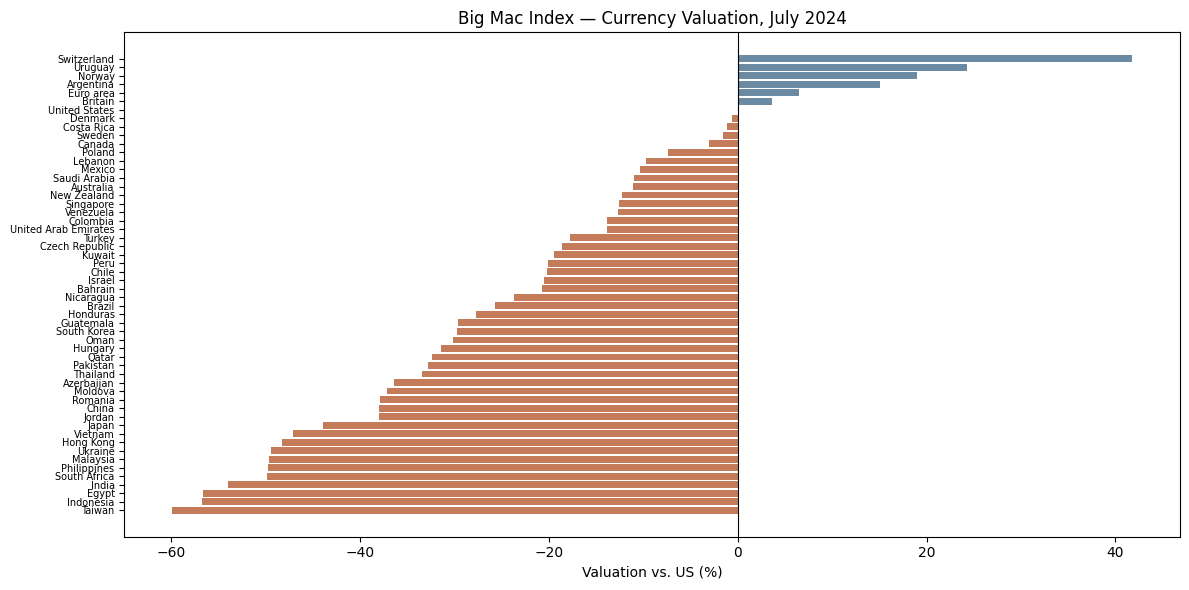


Median valuation: -20.7%
Countries more expensive than US: 6 of 54


In [11]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Visualize the valuation distribution
# -----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))
df_sorted = df_2024.sort_values("valuation_pct")
colors = ["#C47B5A" if v < 0 else "#6B8BA4" for v in df_sorted["valuation_pct"]]
ax.barh(df_sorted["name"], df_sorted["valuation_pct"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Valuation vs. US (%)")
ax.set_title("Big Mac Index — Currency Valuation, July 2024")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig("figures/ch01_bigmac_valuation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMedian valuation: {df_2024['valuation_pct'].median():.1f}%")
print(f"Countries more expensive than US: {(df_2024['valuation_pct'] > 0).sum()} of {len(df_2024)}")

### Interpretation Questions

1. Why are most countries UNDERVALUED relative to the US? What does this tell you about the US price level?
2. Switzerland has been the most overvalued currency in every period since January 2015. What non-tradeable inputs explain this? (Hint: rent, wages, taxes)
3. **Critical question:** If a hedge fund used this chart to make currency bets, would you expect them to make money? Why or why not?

*Your answers here:*

1.
2.
3.

## Part 3: Data Quality & Missing Data (YOUR TASK — 10 min)

Now YOU investigate the dataset's missing data. Which countries have gaps? Why?

In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Diagnose missing data patterns
# -----------------------------------------------------------

# Task 5a: Check overall missing values
print("Missing values per column:")
print(df.isnull().sum())

# Task 5b: Find countries with incomplete panels
# Count how many periods each country appears in
max_periods = df["date"].nunique()
country_counts = df.groupby("name")["date"].count()

# YOUR CODE: Filter to countries with fewer than max_periods observations
incomplete = country_counts[country_counts < max_periods]  # Fill this in

print(f"\nCountries with incomplete panels ({len(incomplete)} of {df['name'].nunique()}):")
print(incomplete.sort_values())

Missing values per column:
date               0
iso_a3             0
currency_code      0
name               0
local_price        0
dollar_ex          0
dollar_price       0
USD_raw            0
EUR_raw            0
GBP_raw            0
JPY_raw            0
CNY_raw            0
GDP_bigmac       254
adj_price        254
USD_adjusted     254
EUR_adjusted     254
GBP_adjusted     254
JPY_adjusted     254
CNY_adjusted     254
dtype: int64

Countries with incomplete panels (32 of 57):
name
Azerbaijan              17
Bahrain                 17
Guatemala               17
Honduras                17
Lebanon                 17
Moldova                 17
Jordan                  17
Kuwait                  17
Nicaragua               17
Romania                 17
Qatar                   17
Oman                    17
United Arab Emirates    17
UAE                     22
Vietnam                 25
India                   31
Venezuela               31
Sri Lanka               35
Russia                  

In [ ]:
# -----------------------------------------------------------
# CHECK — Run as-is after Task 5b
# -----------------------------------------------------------
assert isinstance(incomplete, pd.Series), (
    f"incomplete is a {type(incomplete).__name__}; it should be a Series with one "
    "entry per country -- filter country_counts, not df.")
assert incomplete.dtype != bool, (
    "incomplete holds True/False values. That is the mask itself; put it inside "
    "country_counts[ ... ] to keep the countries where it is True.")
assert (incomplete < max_periods).all(), (
    "incomplete contains a country that appears in every period.")
n_complete = int((country_counts == max_periods).sum())
assert len(incomplete) + n_complete == len(country_counts), (
    f"incomplete has {len(incomplete)} countries and {n_complete} are complete, but "
    f"there are {len(country_counts)} countries: some incomplete ones are missing.")
print(f"Task 5b check passed: {len(incomplete)} incomplete + {n_complete} complete "
      f"= {len(country_counts)} countries.")

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 6: Investigate Russia's disappearance
# -----------------------------------------------------------

# YOUR CODE: Filter the full dataset to Russia only
# Note: filter `df`, the whole panel -- NOT df_2024. df_2024 is one
# cross-section, and Russia is not in it, so that returns zero rows and
# prints an empty table rather than an error.
df_russia = ____  # Fill this in

assert len(df_russia) > 0, "df_russia is empty -- you probably filtered df_2024 instead of df"

# Show the last 5 observations for Russia
print("Russia's last observations:")
print(df_russia[["date", "local_price", "dollar_price"]].tail())

# YOUR CODE: What is the last date Russia appears?
last_date = ____  # Fill this in
print(f"\nRussia's last appearance: {last_date}")
print(f"Russia's total observations: {len(df_russia)} of {max_periods} possible")

In [ ]:
# -----------------------------------------------------------
# CHECK — Run as-is after Task 6
# -----------------------------------------------------------
assert isinstance(df_russia, pd.DataFrame) and len(df_russia) > 0, (
    "df_russia is empty or not a DataFrame -- filter df, the whole panel.")
others = sorted(set(df_russia["name"]) - {"Russia"})
assert not others, f"df_russia also contains rows for {others[:3]}."
assert len(df_russia) == country_counts["Russia"], (
    f"df_russia has {len(df_russia)} rows; Russia appears {country_counts['Russia']} "
    "times in the panel.")
last = pd.Timestamp(last_date)
assert last in set(df_russia["date"]) and (df_russia["date"] <= last).all(), (
    f"{last_date} is not the latest date in df_russia.")
print(f"Task 6 check passed: {len(df_russia)} observations, last on {last.date()}.")

### Missing Data Classification

For each country with an incomplete panel, classify the likely missing data mechanism.
Check the dates before you classify: a country can be incomplete because it
**left** the index, because it **joined late**, or because it has **gaps in the
middle** of its run, and those are different mechanisms.
`df[df["name"] == "Venezuela"]["date"]` shows which one you are looking at.
(`UAE` and `United Arab Emirates` are the same country under two names.)

| Country | Periods Missing | Likely Mechanism | Reasoning |
|---------|----------------|-----------------|----------|
| Russia  |                | MNAR            | McDonald's exited due to geopolitical sanctions |
| Venezuela |              |                 |           |
| (add more) |            |                 |           |

**Key question:** If you drop all countries with incomplete panels and compute the "average PPP deviation," is your result biased? In which direction?

*Your answers here:*



---

## Extension (Optional — 15 min): Time Series Visualization

Track how PPP valuation changes over time for selected countries.

The cell below is **guided** — run it as written first, so you can see the merge-then-compute pattern working. Then do the task at the bottom of the cell: change the list of countries and re-run.

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is, then do the task at the bottom
# -----------------------------------------------------------

# Compute valuation for ALL dates, not just July 2024.
# The US price is the benchmark, and it changes every period — so pull the
# US row for each date and merge it back onto every country in that date.
# (A groupby().apply() would also work, but as of pandas 3.0 it drops the
# grouping column from the result, which would cost us `date` here.)
us_prices = (
    df.loc[df["iso_a3"] == "USA", ["date", "dollar_price"]]
      .rename(columns={"dollar_price": "us_price"})
)

df_full = df.merge(us_prices, on="date", how="inner")
df_full["implied_ppp"] = df_full["local_price"] / df_full["us_price"]
df_full["valuation_pct"] = (
    (df_full["implied_ppp"] - df_full["dollar_ex"]) / df_full["dollar_ex"] * 100
)

# Plot valuation over time for 4 countries
countries = ["Switzerland", "Japan", "Brazil", "China"]
fig, ax = plt.subplots(figsize=(12, 6))
for country in countries:
    subset = df_full[df_full["name"] == country]
    ax.plot(subset["date"], subset["valuation_pct"], label=country, linewidth=2)

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Valuation vs. US (%)")
ax.set_title("Big Mac Index — PPP Valuation Over Time")
ax.legend()
plt.tight_layout()
plt.savefig("figures/ch01_bigmac_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

# YOUR TASK: replace the four names in `countries` above with four countries
# you actually care about, re-run this cell, and write one sentence under the
# chart saying which of them the market has repriced most since 2010.
# (Valid names: run  sorted(df['name'].unique())  to see all of them.)

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# 🤖 README generation — AI writes the docs, not the code
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Loaded the Big Mac Index (57 countries, 45 periods, 2000-04 to 2026-07; 54 in the July 2024 cross-section) from The Economist's GitHub
# * Computed Purchasing Power Parity exchange rates and valuation percentages
# * Identified data structure types (cross-sectional, time series, panel)
# * Diagnosed missing data patterns — classified Russia's exit as MNAR
# * Created visualizations: bar chart of valuations + time series comparison
# * Key finding: Switzerland persistently overvalued -- +41.8% in the July 2024
#   cross-section; Japan undervalued on average in every decade of the series
#
# **Please write a README.md entry including:**
# 1. Project Title: The Data Portfolio — Big Mac Index Analysis
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab01-data-portfolio`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab01-data-portfolio`, tick **Add a README file**, and create it.
2. **Run the whole notebook top to bottom** (**Runtime → Run all**) and check your
   output is showing. The rendered output — charts included — is what is graded.
3. In Colab: **File → Save a copy in GitHub**.
   - **First time only:** a GitHub window asks you to authorize Colab. Sign in, then
     authorize. **If your repo is Private, tick the box granting access to private
     repositories first** — otherwise Colab won't list your repo.
   - Choose `econ3916-lab01-data-portfolio`, branch `main`, commit message
     `Lab 01 submission`, tick **Include a link to Colab**, and click **OK**.
4. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your **repository** URL in the **Comments**
   box — `https://github.com/yourname/econ3916-lab01-data-portfolio`, not the
   link to the notebook file. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install. Stuck? The GitHub Setup page has a
Troubleshooting section.
